# Task 7 - Sales Forecasting

The goal of this project is to build a machine learning regression model that predicts future sales based on historical Walmart sales data.

The project focuses on data cleaning, exploratory data analysis, time-based feature engineering, lag features, time-aware data splitting, regression modeling, and evaluation using MAE, MSE, RMSE, and R².

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

import joblib

## Loading the Data

The dataset contains four CSV files with information about sales, stores, and additional factors that may affect sales.

I will load the files and inspect their shapes before starting the data analysis.

In [2]:
train_df = pd.read_csv("data/train.csv")
features_df = pd.read_csv("data/features.csv")
stores_df = pd.read_csv("data/stores.csv")
test_df = pd.read_csv("data/test.csv")

print("Train shape:", train_df.shape)
print("Features shape:", features_df.shape)
print("Stores shape:", stores_df.shape)
print("Test shape:", test_df.shape)

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)
Test shape: (115064, 4)


In [3]:
print("Train Data:")
display(train_df.head())

print("\nTrain Information:")
train_df.info()

Train Data:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False



Train Information:
<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 17.3 MB


In [4]:
print("Features Data:")
display(features_df.head())

print("\nFeatures Information:")
features_df.info()

Features Data:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



Features Information:
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 791.9 KB


In [5]:
print("Stores Data:")
display(stores_df.head())

print("\nStores Information:")
stores_df.info()

Stores Data:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



Stores Information:
<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Store   45 non-null     int64
 1   Type    45 non-null     str  
 2   Size    45 non-null     int64
dtypes: int64(2), str(1)
memory usage: 1.2 KB


In [6]:
print("Test Data:")
display(test_df.head())

print("\nTest Information:")
test_df.info()

Test Data:


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False



Test Information:
<class 'pandas.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   Store      115064 non-null  int64
 1   Dept       115064 non-null  int64
 2   Date       115064 non-null  str  
 3   IsHoliday  115064 non-null  bool 
dtypes: bool(1), int64(2), str(1)
memory usage: 3.8 MB


## Checking Data Quality

Before cleaning the data, I will check for missing values, duplicate rows, and basic statistics to identify any data quality issues.

In [7]:
print("Missing values in Train:")
print(train_df.isnull().sum())

print("\nMissing values in Features:")
print(features_df.isnull().sum())

print("\nMissing values in Stores:")
print(stores_df.isnull().sum())

print("\nMissing values in Test:")
print(test_df.isnull().sum())

print("\nDuplicate rows:")
print("Train:", train_df.duplicated().sum())
print("Features:", features_df.duplicated().sum())
print("Stores:", stores_df.duplicated().sum())
print("Test:", test_df.duplicated().sum())

Missing values in Train:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Missing values in Features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Missing values in Stores:
Store    0
Type     0
Size     0
dtype: int64

Missing values in Test:
Store        0
Dept         0
Date         0
IsHoliday    0
dtype: int64

Duplicate rows:
Train: 0
Features: 0
Stores: 0
Test: 0


## Basic Data Exploration

I will explore the main characteristics of the sales data, including the date range, number of stores and departments, and sales statistics.


In [8]:
print("Date range:")
print("Start:", train_df["Date"].min())
print("End:", train_df["Date"].max())

print("\nNumber of stores:", train_df["Store"].nunique())
print("Number of departments:", train_df["Dept"].nunique())

print("\nWeekly Sales statistics:")
print(train_df["Weekly_Sales"].describe())

print("\nHoliday distribution:")
print(train_df["IsHoliday"].value_counts())

Date range:
Start: 2010-02-05
End: 2012-10-26

Number of stores: 45
Number of departments: 81

Weekly Sales statistics:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

Holiday distribution:
IsHoliday
False    391909
True      29661
Name: count, dtype: int64


## Weekly Sales Distribution

I will visualize the distribution of weekly sales to understand the spread of the target variable and identify unusual values.


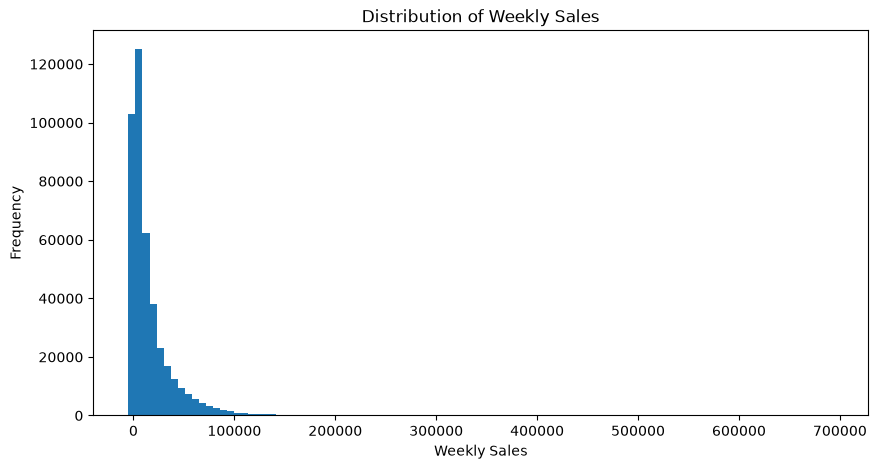

In [9]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["Weekly_Sales"], bins=100)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

## Sales Trend Over Time

I will aggregate weekly sales by date and visualize the overall sales trend over time.


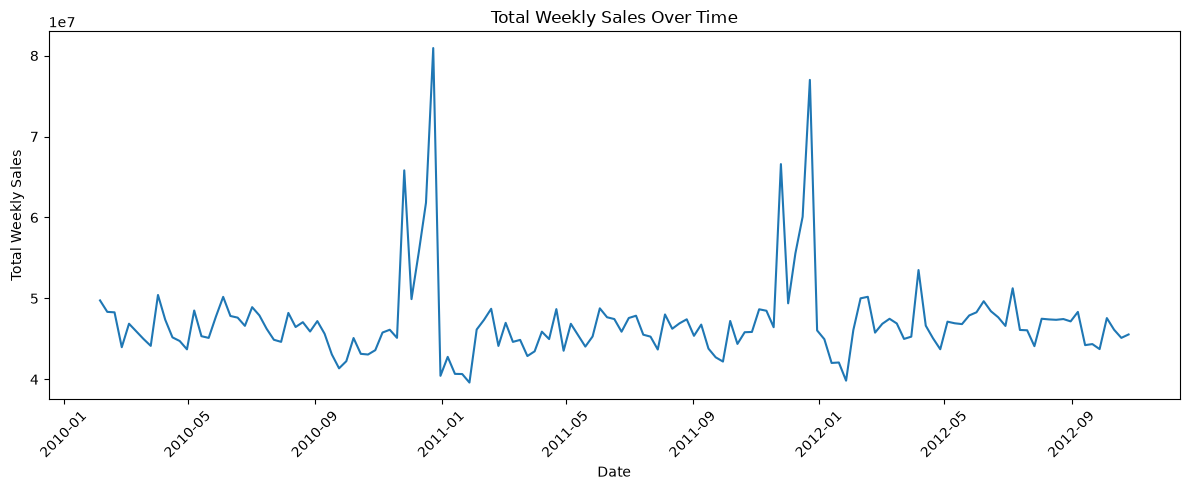

In [10]:
weekly_sales = (
    train_df.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

weekly_sales["Date"] = pd.to_datetime(weekly_sales["Date"])

plt.figure(figsize=(12, 5))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"]
)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Holiday vs Non-Holiday Sales

I will compare total weekly sales during holiday and non-holiday weeks to examine the effect of holidays on sales.


IsHoliday
False    6.231919e+09
True     5.052996e+08
Name: Weekly_Sales, dtype: float64


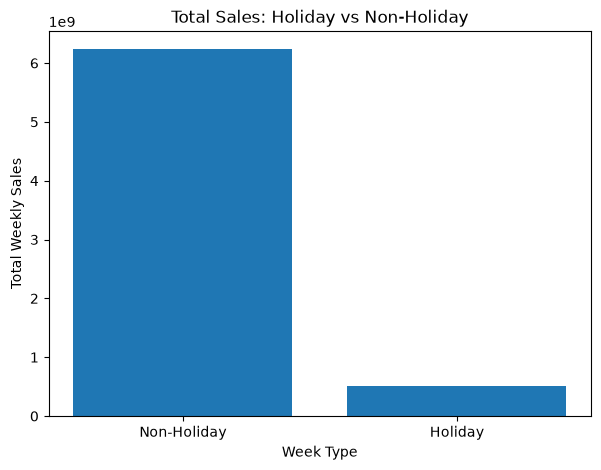

In [11]:
holiday_sales = (
    train_df.groupby("IsHoliday")["Weekly_Sales"]
    .sum()
)

print(holiday_sales)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Holiday", "Holiday"],
    [
        holiday_sales[False],
        holiday_sales[True]
    ]
)

plt.title("Total Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Total Weekly Sales")

plt.show()

## Average Sales by Holiday Status

I will compare the average weekly sales for holiday and non-holiday weeks to account for the different number of observations.


IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


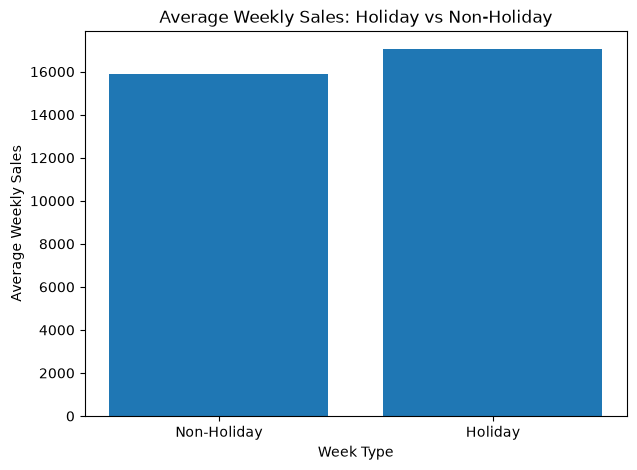

In [12]:
average_holiday_sales = (
    train_df.groupby("IsHoliday")["Weekly_Sales"]
    .mean()
)

print(average_holiday_sales)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-Holiday", "Holiday"],
    [
        average_holiday_sales[False],
        average_holiday_sales[True]
    ]
)

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")

plt.show()

## Checking Negative Sales

The sales data contains some negative weekly sales values, so I will inspect them before deciding how to handle them.


In [13]:
negative_sales = train_df[train_df["Weekly_Sales"] < 0]

print("Number of negative sales:", len(negative_sales))

print(
    "Percentage of negative sales:",
    len(negative_sales) / len(train_df) * 100
)

print("\nNegative sales values:")
print(negative_sales["Weekly_Sales"].describe())

print("\nExamples:")
print(negative_sales.head(10))

Number of negative sales: 1285
Percentage of negative sales: 0.30481296107408024

Negative sales values:
count    1285.000000
mean      -68.608218
std       231.664245
min     -4988.940000
25%       -41.000000
50%       -13.200000
75%        -4.940000
max        -0.020000
Name: Weekly_Sales, dtype: float64

Examples:
      Store  Dept        Date  Weekly_Sales  IsHoliday
846       1     6  2012-08-10       -139.65      False
2384      1    18  2012-05-04         -1.27      False
6048      1    47  2010-02-19       -863.00      False
6049      1    47  2010-03-12       -698.00      False
6051      1    47  2010-10-08        -58.00      False
6056      1    47  2011-04-08       -298.00      False
6057      1    47  2011-07-08       -198.00      False
6061      1    47  2011-10-14       -498.00      False
6062      1    47  2011-12-23       -498.00      False
6063      1    47  2012-02-17       -198.00      False


## Converting Date Column

The Date column is stored as text, so I will convert it to datetime format to support time-based analysis and feature engineering.


In [14]:
train_df["Date"] = pd.to_datetime(train_df["Date"])
features_df["Date"] = pd.to_datetime(features_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

print(train_df.dtypes)

Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
dtype: object


## Inspecting Missing Feature Values

I will inspect the missing values in the feature dataset and examine the available values before choosing an appropriate cleaning method.


In [15]:
missing_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment"
]

print("Missing percentages:")
print(
    features_df[missing_columns]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

print("\nSummary statistics:")
print(
    features_df[missing_columns]
    .describe()
)

Missing percentages:
MarkDown1       50.77
MarkDown2       64.33
MarkDown3       55.89
MarkDown4       57.70
MarkDown5       50.55
CPI              7.14
Unemployment     7.14
dtype: float64

Summary statistics:
           MarkDown1      MarkDown2      MarkDown3     MarkDown4  \
count    4032.000000    2921.000000    3613.000000   3464.000000   
mean     7032.371786    3384.176594    1760.100180   3292.935886   
std      9262.747448    8793.583016   11276.462208   6792.329861   
min     -2781.450000    -265.760000    -179.260000      0.220000   
25%      1577.532500      68.880000       6.600000    304.687500   
50%      4743.580000     364.570000      36.260000   1176.425000   
75%      8923.310000    2153.350000     163.150000   3310.007500   
max    103184.980000  104519.540000  149483.310000  67474.850000   

           MarkDown5          CPI  Unemployment  
count    4050.000000  7605.000000   7605.000000  
mean     4132.216422   172.460809      7.826821  
std     13086.690278    39

## Handling Missing Values

The Markdown columns contain many missing values because these promotional variables were not available for every week.

I will replace missing Markdown values with zero, while CPI and Unemployment values will be filled using time-based interpolation.


In [16]:
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

features_df[markdown_columns] = (
    features_df[markdown_columns]
    .fillna(0)
)

features_df = features_df.sort_values(
    ["Store", "Date"]
)

features_df[["CPI", "Unemployment"]] = (
    features_df
    .groupby("Store")[["CPI", "Unemployment"]]
    .transform(
        lambda group: group.interpolate(
            method="linear",
            limit_direction="both"
        )
    )
)

print("Missing values after cleaning:")
print(features_df.isnull().sum())

Missing values after cleaning:
Store           0
Date            0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday       0
dtype: int64


## Merging the Datasets

I will merge the sales data with the external features and store information to create one dataset for modeling.


In [17]:
sales_df = train_df.merge(
    features_df,
    on=["Store", "Date"],
    how="left",
    suffixes=("", "_feature")
)

sales_df = sales_df.merge(
    stores_df,
    on="Store",
    how="left"
)

print("Merged dataset shape:", sales_df.shape)
print("\nColumns:")
print(sales_df.columns.tolist())

print("\nMissing values after merging:")
print(sales_df.isnull().sum())

Merged dataset shape: (421570, 17)

Columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_feature', 'Type', 'Size']

Missing values after merging:
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1            0
MarkDown2            0
MarkDown3            0
MarkDown4            0
MarkDown5            0
CPI                  0
Unemployment         0
IsHoliday_feature    0
Type                 0
Size                 0
dtype: int64


## Removing Duplicate Feature Column

The IsHoliday column appears in both the sales and feature datasets, so I will remove the duplicate feature column.


In [18]:
sales_df = sales_df.drop(
    columns=["IsHoliday_feature"]
)

print("Dataset shape:", sales_df.shape)
print("\nColumns:")
print(sales_df.columns.tolist())

Dataset shape: (421570, 16)

Columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


## Final Data Quality Check

I will perform a final check on the cleaned dataset to confirm that there are no missing values or duplicate rows before feature engineering.


In [19]:
print("Missing values:")
print(sales_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(sales_df.duplicated().sum())

print("\nData types:")
print(sales_df.dtypes)

print("\nFinal shape:")
print(sales_df.shape)

Missing values:
0

Duplicate rows:
0

Data types:
Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                       str
Size                     int64
dtype: object

Final shape:
(421570, 16)


## Creating Time-Based Features

I will extract time-based features from the Date column, including the day, month, and week number.

In [20]:
sales_df["Year"] = sales_df["Date"].dt.year
sales_df["Month"] = sales_df["Date"].dt.month
sales_df["Week"] = sales_df["Date"].dt.isocalendar().week.astype(int)
sales_df["Day"] = sales_df["Date"].dt.day

print(
    sales_df[
        ["Date", "Day", "Year", "Month", "Week"]
    ].head()
)

        Date  Day  Year  Month  Week
0 2010-02-05    5  2010      2     5
1 2010-02-12   12  2010      2     6
2 2010-02-19   19  2010      2     7
3 2010-02-26   26  2010      2     8
4 2010-03-05    5  2010      3     9


## Creating Lag Features

Lag features use previous sales values to help the model learn patterns from historical sales.

The lag values will be calculated separately for each store and department to avoid mixing sales from different groups.


In [21]:
sales_df = sales_df.sort_values(
    ["Store", "Dept", "Date"]
)

grouped_sales = sales_df.groupby(
    ["Store", "Dept"]
)["Weekly_Sales"]

sales_df["Lag_1"] = grouped_sales.shift(1)
sales_df["Lag_2"] = grouped_sales.shift(2)
sales_df["Lag_4"] = grouped_sales.shift(4)

print(
    sales_df[
        [
            "Store",
            "Dept",
            "Date",
            "Weekly_Sales",
            "Lag_1",
            "Lag_2",
            "Lag_4"
        ]
    ].head(10)
)

   Store  Dept       Date  Weekly_Sales     Lag_1     Lag_2     Lag_4
0      1     1 2010-02-05      24924.50       NaN       NaN       NaN
1      1     1 2010-02-12      46039.49  24924.50       NaN       NaN
2      1     1 2010-02-19      41595.55  46039.49  24924.50       NaN
3      1     1 2010-02-26      19403.54  41595.55  46039.49       NaN
4      1     1 2010-03-05      21827.90  19403.54  41595.55  24924.50
5      1     1 2010-03-12      21043.39  21827.90  19403.54  46039.49
6      1     1 2010-03-19      22136.64  21043.39  21827.90  41595.55
7      1     1 2010-03-26      26229.21  22136.64  21043.39  19403.54
8      1     1 2010-04-02      57258.43  26229.21  22136.64  21827.90
9      1     1 2010-04-09      42960.91  57258.43  26229.21  21043.39


## Handling Lag Missing Values

The first few records of each store and department do not have enough historical sales to calculate all lag features.

These rows will be removed before modeling because the required lag values are unavailable.


In [22]:
lag_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_4"
]

print("Rows before removing lag missing values:", len(sales_df))

sales_df = sales_df.dropna(
    subset=lag_columns
).reset_index(drop=True)

print("Rows after removing lag missing values:", len(sales_df))

print("\nMissing values in lag features:")
print(sales_df[lag_columns].isnull().sum())

Rows before removing lag missing values: 421570
Rows after removing lag missing values: 408436

Missing values in lag features:
Lag_1    0
Lag_2    0
Lag_4    0
dtype: int64


## Creating a Rolling Average

A rolling average can capture recent sales patterns by averaging previous weeks.

The calculation will use only past sales values to prevent data leakage.


In [23]:
sales_df["Rolling_Mean_4"] = (
    sales_df
    .groupby(["Store", "Dept"])["Weekly_Sales"]
    .transform(
        lambda x: x.shift(1).rolling(window=4).mean()
    )
)

print(
    sales_df[
        [
            "Store",
            "Dept",
            "Date",
            "Weekly_Sales",
            "Lag_1",
            "Lag_2",
            "Lag_4",
            "Rolling_Mean_4"
        ]
    ].head(10)
)

   Store  Dept       Date  Weekly_Sales     Lag_1     Lag_2     Lag_4  \
0      1     1 2010-03-05      21827.90  19403.54  41595.55  24924.50   
1      1     1 2010-03-12      21043.39  21827.90  19403.54  46039.49   
2      1     1 2010-03-19      22136.64  21043.39  21827.90  41595.55   
3      1     1 2010-03-26      26229.21  22136.64  21043.39  19403.54   
4      1     1 2010-04-02      57258.43  26229.21  22136.64  21827.90   
5      1     1 2010-04-09      42960.91  57258.43  26229.21  21043.39   
6      1     1 2010-04-16      17596.96  42960.91  57258.43  22136.64   
7      1     1 2010-04-23      16145.35  17596.96  42960.91  26229.21   
8      1     1 2010-04-30      16555.11  16145.35  17596.96  57258.43   
9      1     1 2010-05-07      17413.94  16555.11  16145.35  42960.91   

   Rolling_Mean_4  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4      22809.2850  
5      31666.9175  
6      37146.2975  
7      36011.3775  
8      33490.412

## Handling Rolling Average Missing Values

The first four records of each store and department do not have enough previous sales values to calculate the four-week rolling average.

These rows will be removed before modeling because the rolling feature cannot be calculated reliably for them.


In [24]:
print(
    "Rows before removing rolling average missing values:",
    len(sales_df)
)

sales_df = sales_df.dropna(
    subset=["Rolling_Mean_4"]
).reset_index(drop=True)

print(
    "Rows after removing rolling average missing values:",
    len(sales_df)
)

print("\nMissing values:")
print(
    sales_df["Rolling_Mean_4"].isnull().sum()
)

Rows before removing rolling average missing values: 408436
Rows after removing rolling average missing values: 395604

Missing values:
0


## Preparing Features and Target

The dataset contains the store Type as a categorical feature, so it needs to be converted into numerical values before modeling.

I will also separate the input features from the target variable, Weekly_Sales.


In [25]:
sales_df = pd.get_dummies(
    sales_df,
    columns=["Type"],
    drop_first=True
)

features = [
    "Store",
    "Dept",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Month",
    "Week",
    "Day",
    "Lag_1",
    "Lag_2",
    "Lag_4",
    "Rolling_Mean_4",
    "Type_B",
    "Type_C"
]

X = sales_df[features]
y = sales_df["Weekly_Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (395604, 23)
Target shape: (395604,)

Feature columns:
['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Day', 'Lag_1', 'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Type_B', 'Type_C']


## Time-Based Train/Test Split

Since this is a time series forecasting problem, the data must be split chronologically.

The split is based on unique dates so that each week belongs entirely to either the training set or the testing set. This prevents the same week from appearing in both sets and preserves the time order of the data.

In [26]:
unique_dates = sorted(
    sales_df["Date"].unique()
)

split_date_index = int(
    len(unique_dates) * 0.8
)

split_date = unique_dates[split_date_index]

train_data = sales_df[
    sales_df["Date"] < split_date
].copy()

test_data = sales_df[
    sales_df["Date"] >= split_date
].copy()

X_train = train_data[features]
y_train = train_data["Weekly_Sales"]

X_test = test_data[features]
y_test = test_data["Weekly_Sales"]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining period:")
print(
    train_data["Date"].min(),
    "to",
    train_data["Date"].max()
)

print("\nTesting period:")
print(
    test_data["Date"].min(),
    "to",
    test_data["Date"].max()
)

print("\nOverlapping dates:")
print(
    len(
        set(train_data["Date"])
        .intersection(
            set(test_data["Date"])
        )
    )
)

Training data shape: (315880, 23)
Testing data shape: (79724, 23)

Training period:
2010-04-02 00:00:00 to 2012-04-20 00:00:00

Testing period:
2012-04-27 00:00:00 to 2012-10-26 00:00:00

Overlapping dates:
0


## Training the Linear Regression Model

I will first train a Linear Regression model as a baseline.

This model will provide a reference point for evaluating other regression models later.


In [27]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred_linear = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## Evaluating the Linear Regression Model

The model will be evaluated using MAE, MSE, RMSE, and R².

These metrics measure the prediction error and how well the model explains the variation in weekly sales.


In [28]:
mae_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mse_linear
)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Results
-------------------------
MAE: 1708.7801780349025
MSE: 10743944.42270337
RMSE: 3277.7956651846634
R²: 0.9777955443310955


## Random Forest Regression

I will train a Random Forest Regressor to compare its performance with the Linear Regression baseline.

Random Forest can capture non-linear relationships between historical sales, time-based features, and other factors.


In [29]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    X_test
)

print("Random Forest Regression trained successfully.")

Random Forest Regression trained successfully.


## Evaluating the Random Forest Model

The Random Forest model will be evaluated using the same metrics as the baseline model.

This allows a direct comparison between the two regression models.


In [30]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mse_rf
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest Results")
print("---------------------")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
---------------------
MAE: 1359.9696872133864
MSE: 8134542.10821238
RMSE: 2852.111868109731
R²: 0.9831883829139176


## Actual vs Predicted Sales

I will compare the actual and predicted sales over the testing period.

The predictions will be aggregated by date to visualize the overall weekly sales trend.


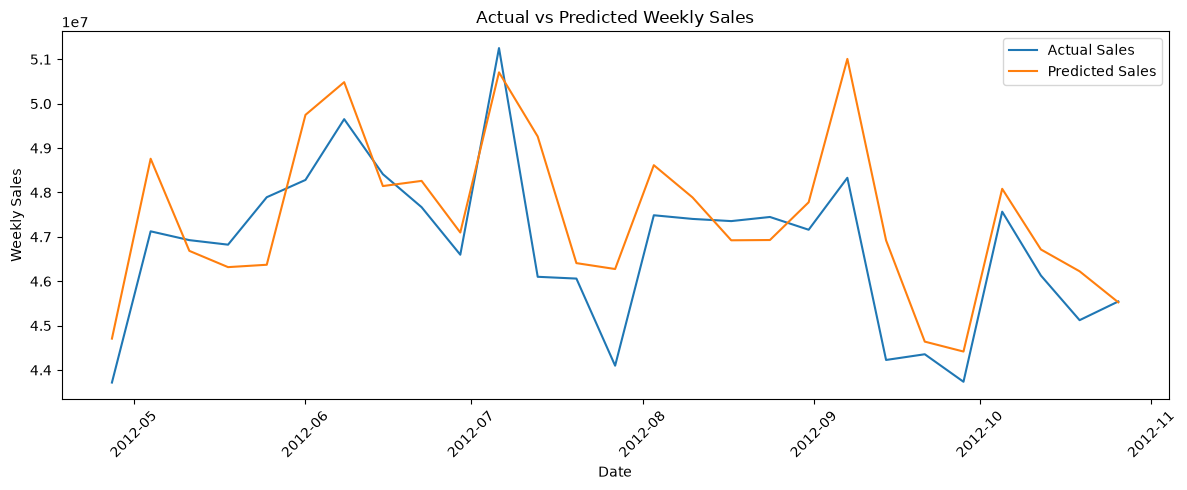

In [31]:
comparison_df = test_data[
    ["Date", "Weekly_Sales"]
].copy()

comparison_df["Predicted_Sales"] = y_pred_rf

weekly_comparison = (
    comparison_df
    .groupby("Date")[
        ["Weekly_Sales", "Predicted_Sales"]
    ]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    weekly_comparison["Date"],
    weekly_comparison["Weekly_Sales"],
    label="Actual Sales"
)

plt.plot(
    weekly_comparison["Date"],
    weekly_comparison["Predicted_Sales"],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Model Comparison

The two regression models will be compared using the evaluation metrics calculated on the same testing period.

The model with lower prediction errors and higher R² will be selected as the final model.


In [32]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear,
        mae_rf
    ],
    "MSE": [
        mse_linear,
        mse_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R²": [
        r2_linear,
        r2_rf
    ]
})

print(model_comparison)

               Model          MAE           MSE         RMSE        R²
0  Linear Regression  1708.780178  1.074394e+07  3277.795665  0.977796
1      Random Forest  1359.969687  8.134542e+06  2852.111868  0.983188


## Feature Importance

The Random Forest model provides feature importance values that show how much each feature contributed to the model's predictions.

I will visualize the most important features used by the model.

In [33]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

           Feature  Importance
17           Lag_1    0.745737
20  Rolling_Mean_4    0.181376
19           Lag_4    0.018554
15            Week    0.010311
18           Lag_2    0.009242
1             Dept    0.006450
7        MarkDown3    0.005270
16             Day    0.004835
3      Temperature    0.002318
11    Unemployment    0.002255
12            Size    0.002069
4       Fuel_Price    0.001839
2        IsHoliday    0.001786
10             CPI    0.001769
0            Store    0.001667
14           Month    0.000995
6        MarkDown2    0.000822
9        MarkDown5    0.000813
5        MarkDown1    0.000715
8        MarkDown4    0.000623
21          Type_B    0.000333
13            Year    0.000191
22          Type_C    0.000031


## Top 10 Feature Importance

The top ten features will be visualized to make the most influential variables easier to compare.


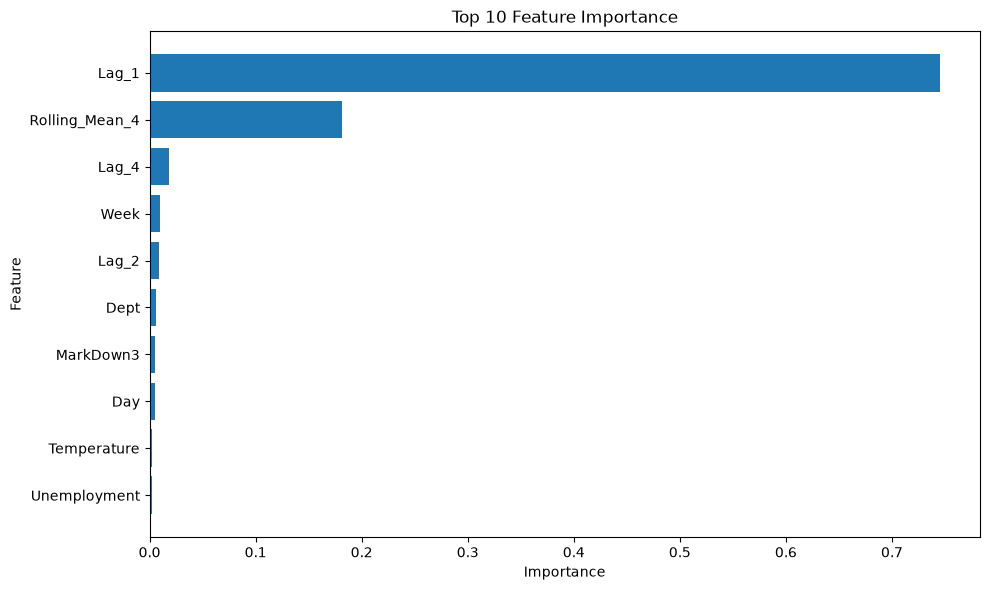

In [34]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Saving the Final Model

The Random Forest model achieved the best performance among the tested regression models.

I will save the trained model together with the feature names used during training so it can be reused later.


In [35]:
model_artifact = {
    "model": random_forest_model,
    "features": features
}

joblib.dump(
    model_artifact,
    "artifacts/sales_forecasting_model.pkl"
)

print(
    "Final model saved successfully."
)

Final model saved successfully.


## Testing the Saved Model

I will reload the saved model and use it to generate predictions on the testing data.

This confirms that the saved artifact can be loaded and reused successfully.


In [36]:
loaded_artifact = joblib.load(
    "artifacts/sales_forecasting_model.pkl"
)

loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["features"]

loaded_predictions = loaded_model.predict(
    X_test[loaded_features]
)

print("Saved model loaded successfully.")
print("Number of predictions:", len(loaded_predictions))
print("Number of features:", len(loaded_features))

Saved model loaded successfully.
Number of predictions: 79724
Number of features: 23


In [37]:
print(
    "Predictions match:",
    np.allclose(
        y_pred_rf,
        loaded_predictions
    )
)

Predictions match: True


## Bonus: Rolling Averages

A four-week rolling average was created to capture the recent sales trend for each Store and Department.

The current week's sales are excluded from the calculation by shifting the sales values by one week before calculating the rolling average. This prevents data leakage.


## Seasonal Decomposition

Seasonal decomposition is used to separate the weekly sales time series into trend, seasonal, and residual components.

Because the data is recorded weekly, a period of 52 weeks is used to represent an approximate yearly seasonal cycle.


In [38]:
weekly_sales = (
    sales_df
    .groupby("Date")["Weekly_Sales"]
    .sum()
    .sort_index()
)

print("Number of weeks:", len(weekly_sales))
print("Start date:", weekly_sales.index.min())
print("End date:", weekly_sales.index.max())

Number of weeks: 135
Start date: 2010-04-02 00:00:00
End date: 2012-10-26 00:00:00


In [39]:
decomposition = seasonal_decompose(
    weekly_sales,
    model="additive",
    period=52
)

print("Seasonal decomposition completed successfully.")

Seasonal decomposition completed successfully.


I will plot the four components of the weekly sales time series to better understand its behavior over time.

The decomposition separates the series into the original sales, long-term trend, seasonal pattern, and residual component.


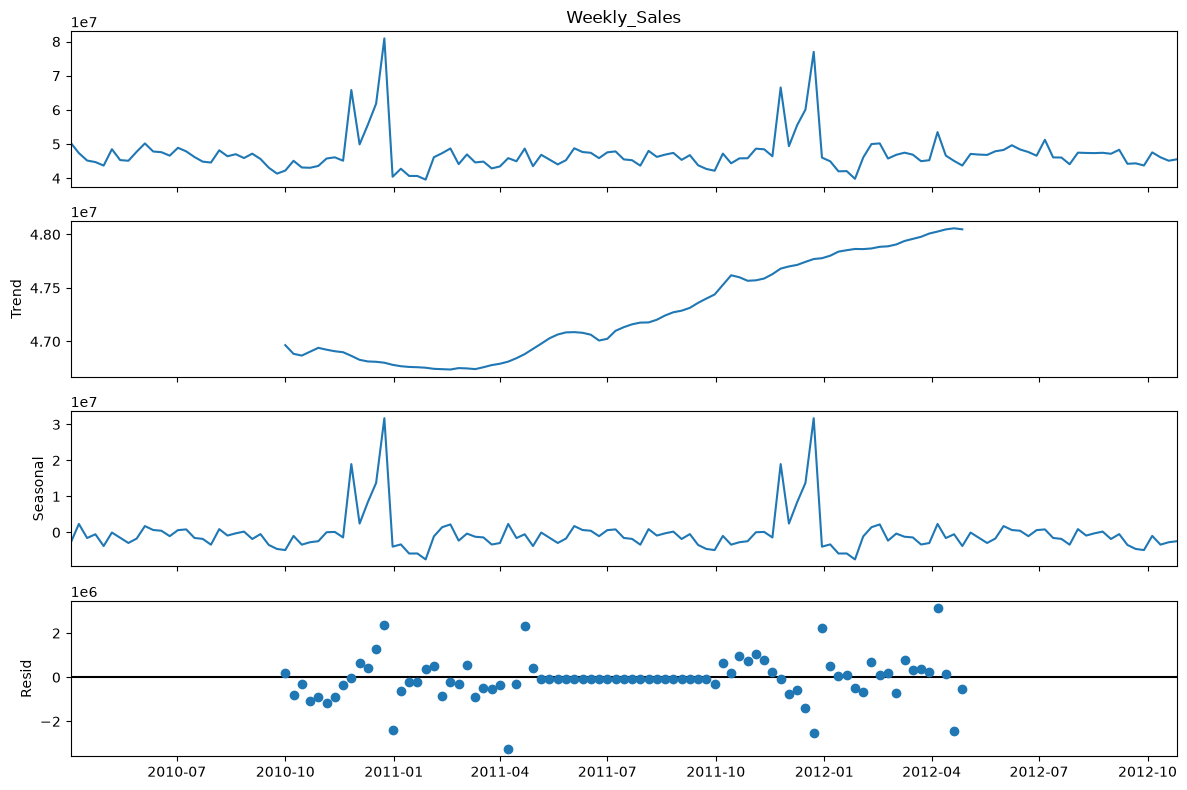

In [40]:
fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.tight_layout()
plt.show()

## Decomposition Interpretation

The decomposition shows a clear upward trend in the overall weekly sales over the analyzed period.

The seasonal component captures recurring yearly patterns, including stronger sales around holiday and year-end periods.

The residual component is mostly centered around zero, with some larger deviations around major sales spikes that are not completely explained by the trend and seasonal components.

Overall, the decomposition shows that Walmart sales contain both a long-term trend and recurring seasonal patterns.


## XGBoost with Time-Aware Validation

XGBoost is an additional gradient boosting regression model that can capture non-linear relationships between the engineered features and weekly sales.

TimeSeriesSplit is used to evaluate the model while preserving the chronological order of the data.


## Time-Aware Validation

I will use TimeSeriesSplit to evaluate the XGBoost model while preserving the chronological order of the sales data.

In each split, the model is trained on earlier observations and validated on later observations.


In [41]:
train_data = train_data.sort_values(
    "Date"
).reset_index(drop=True)

X_train = train_data[features]
y_train = train_data["Weekly_Sales"]

tscv = TimeSeriesSplit(n_splits=3)

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train),
    start=1
):
    print(f"Fold {fold}")
    print("Training samples:", len(train_index))
    print("Validation samples:", len(validation_index))
    print()

Fold 1
Training samples: 78970
Validation samples: 78970

Fold 2
Training samples: 157940
Validation samples: 78970

Fold 3
Training samples: 236910
Validation samples: 78970



In [42]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

fold_results = []

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train),
    start=1
):
    X_fold_train = X_train.iloc[train_index]
    y_fold_train = y_train.iloc[train_index]

    X_fold_validation = X_train.iloc[validation_index]
    y_fold_validation = y_train.iloc[validation_index]

    xgb_model.fit(
        X_fold_train,
        y_fold_train
    )

    y_fold_pred = xgb_model.predict(
        X_fold_validation
    )

    mae = mean_absolute_error(
        y_fold_validation,
        y_fold_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_fold_validation,
            y_fold_pred
        )
    )

    r2 = r2_score(
        y_fold_validation,
        y_fold_pred
    )

    fold_results.append({
        "Fold": fold,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

xgb_cv_results = pd.DataFrame(fold_results)

print(xgb_cv_results)

   Fold          MAE         RMSE        R²
0     1  2770.234714  9170.127004  0.854598
1     2  1453.130529  3185.915943  0.978429
2     3  1990.307637  5383.840306  0.951038


## XGBoost Validation Results

The results from the time-aware validation folds will be averaged to obtain an overall estimate of the XGBoost performance.

This provides a more reliable evaluation than using a single validation period.


In [43]:
print("Average Time-Aware Validation Results")
print("-------------------------------------")
print("Mean MAE:", xgb_cv_results["MAE"].mean())
print("Mean RMSE:", xgb_cv_results["RMSE"].mean())
print("Mean R²:", xgb_cv_results["R²"].mean())

Average Time-Aware Validation Results
-------------------------------------
Mean MAE: 2071.224293449386
Mean RMSE: 5913.294417881746
Mean R²: 0.9280216127956672


## Bonus: Model Comparison
The XGBoost results will be compared with the Random Forest model used in the main task.

The Random Forest results were obtained from the final chronological test period, while the XGBoost results are based on time-aware validation folds. Therefore, this comparison is presented as an additional analysis rather than a direct replacement of the main test evaluation.


In [44]:
print("Random Forest Test Results")
print("--------------------------")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

print("\nXGBoost Time-Aware Validation Results")
print("--------------------------------------")
print("Mean MAE:", xgb_cv_results["MAE"].mean())
print("Mean RMSE:", xgb_cv_results["RMSE"].mean())
print("Mean R²:", xgb_cv_results["R²"].mean())

Random Forest Test Results
--------------------------
MAE: 1359.9696872133864
RMSE: 2852.111868109731
R²: 0.9831883829139176

XGBoost Time-Aware Validation Results
--------------------------------------
Mean MAE: 2071.224293449386
Mean RMSE: 5913.294417881746
Mean R²: 0.9280216127956672


## XGBoost Interpretation

The XGBoost model was evaluated using three time-aware validation folds.

The validation results varied across the folds, with R² values ranging from 0.853 to 0.978. The average R² across the three folds was 0.928, with a mean MAE of 2071.22 and a mean RMSE of 5913.29.

The variation between the folds shows that model performance can change across different time periods.

The Random Forest model from the main task was evaluated separately on the final held-out test period, so its test metrics should not be directly compared with the XGBoost cross-validation averages.

The XGBoost experiment was included as an additional bonus analysis while Random Forest remains the final model selected for the main task.

## Final Conclusion

The Walmart sales dataset was used to build a machine learning regression model for weekly sales forecasting.

The data was cleaned and merged with store and external feature information. Time-based features such as Year, Month, Week, and Day were created, along with lag features and a four-week rolling average based only on previous sales values.

The data was split chronologically into training and testing periods to preserve the time order and avoid data leakage.

Linear Regression and Random Forest were trained and evaluated using MAE, MSE, RMSE, and R². The Random Forest model achieved better performance among the tested regression models, with an MAE of 1359.97, RMSE of 2852.11, and R² of 0.9832 on the testing period.

The actual and predicted weekly sales were also visualized over time to compare the model's forecasting performance.

As additional analysis, a seasonal decomposition was performed to examine the trend and yearly seasonal patterns in weekly sales. XGBoost was also evaluated using time-aware validation with three chronological folds.

Finally, the trained Random Forest model was saved and successfully reloaded, confirming that it can be reused for future predictions.